# Part A — Data Investigation

**Objective:** Exploratory analysis to understand statistical structure and feature behavior.

In [5]:

from google.colab import drive
drive.mount('/content/drive')

# Update these paths to where you placed the files in your Drive
TRAIN_PATH = '/content/drive/MyDrive/cassandra/veritas_train_cass.csv'
TEST_PATH  = '/content/drive/MyDrive/cassandra/veritas_test_cass.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('darkgrid')
PALETTE = ['#2ecc71', '#e74c3c']

print('Libraries loaded ✓')

Libraries loaded ✓


In [7]:

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head(3)

Train shape : (148463, 59)
Test  shape : (178564, 58)


,id,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin,target
0,1,1.0,1.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,3.0,7.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,2,5.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,...,3.0,3.0,7.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,3,3.0,1.0,7.0,1.0,5.0,0.0,0.0,1.0,0.0,...,4.0,2.0,7.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0


## A1 — Feature Understanding and Metadata

In [8]:

features = [c for c in train.columns if c not in ['id', 'target']]

bin_feats  = [f for f in features if f.endswith('_bin')]
cat_feats  = [f for f in features if f.endswith('_cat')]
cont_feats = [f for f in features if f not in bin_feats + cat_feats]

print(f'Binary features      : {len(bin_feats)}')
print(f'Categorical features : {len(cat_feats)}')
print(f'Continuous/Ordinal   : {len(cont_feats)}')
print(f'Total features       : {len(features)}')

Binary features      : 17
Categorical features : 14
Continuous/Ordinal   : 26
Total features       : 57


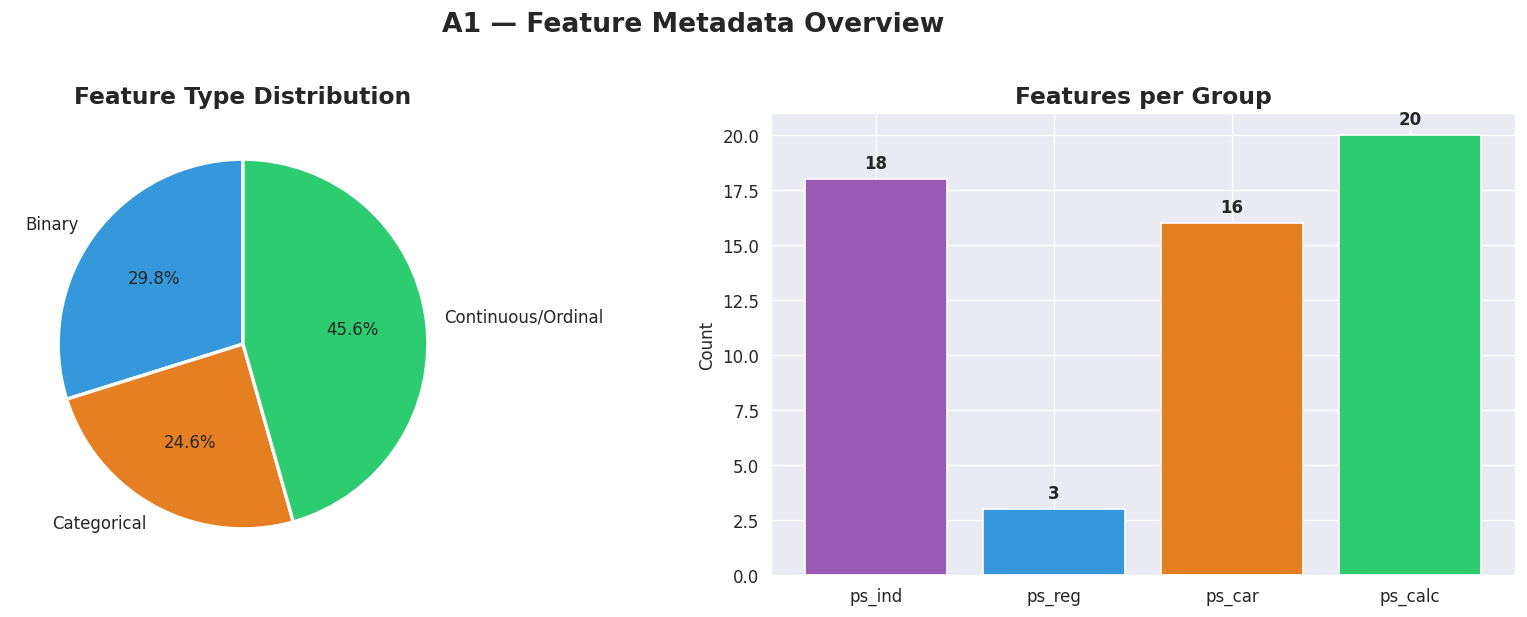

Saved: A1_feature_metadata.png


In [9]:
# ── Feature Groups by Prefix ─────────────────────────────────────────
prefixes = ['ps_ind', 'ps_reg', 'ps_car', 'ps_calc']
group_counts = {}
for p in prefixes:
    group_counts[p] = len([f for f in features if f.startswith(p)])

# ── Plot 1: Feature Type Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - feature types
type_counts = {'Binary': len(bin_feats), 'Categorical': len(cat_feats), 'Continuous/Ordinal': len(cont_feats)}
axes[0].pie(type_counts.values(), labels=type_counts.keys(),
            autopct='%1.1f%%', colors=['#3498db','#e67e22','#2ecc71'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Feature Type Distribution', fontsize=14, fontweight='bold')

# Bar chart - feature groups
bars = axes[1].bar(group_counts.keys(), group_counts.values(),
                   color=['#9b59b6','#3498db','#e67e22','#2ecc71'], edgecolor='white')
for bar, val in zip(bars, group_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Features per Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('A1 — Feature Metadata Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('A1_feature_metadata.png', bbox_inches='tight')
plt.show()
print('Saved: A1_feature_metadata.png')

In [10]:
# ── Metadata Summary Table ────────────────────────────────────────────
meta = pd.DataFrame({
    'feature': features,
    'type': ['binary' if f in bin_feats else 'categorical' if f in cat_feats else 'continuous' for f in features],
    'group': [next((p for p in prefixes if f.startswith(p)), 'other') for f in features],
    'n_unique': [train[f].nunique() for f in features],
    'missing_count': [(train[f] == -1).sum() for f in features],
    'missing_pct': [(train[f] == -1).mean() * 100 for f in features]
})

print('Features with missing values (-1):')
print(meta[meta['missing_count'] > 0][['feature','type','group','missing_count','missing_pct']]
      .sort_values('missing_pct', ascending=False).to_string(index=False))

Features with missing values (-1):
      feature        type  group  missing_count  missing_pct
ps_car_03_cat categorical ps_car         102542    69.069061
ps_car_05_cat categorical ps_car          66455    44.761995
    ps_reg_03  continuous ps_reg          26912    18.127075
    ps_car_14  continuous ps_car          10744     7.236820
ps_car_07_cat categorical ps_car           2899     1.952675
ps_ind_05_cat categorical ps_ind           1452     0.978021
ps_car_09_cat categorical ps_car            174     0.117201
ps_ind_02_cat categorical ps_ind             54     0.036373
ps_car_01_cat categorical ps_car             26     0.017513
ps_ind_04_cat categorical ps_ind             20     0.013471
ps_car_02_cat categorical ps_car              1     0.000674
    ps_car_11  continuous ps_car              1     0.000674


## A2 — Target Distribution and Feature Distributions

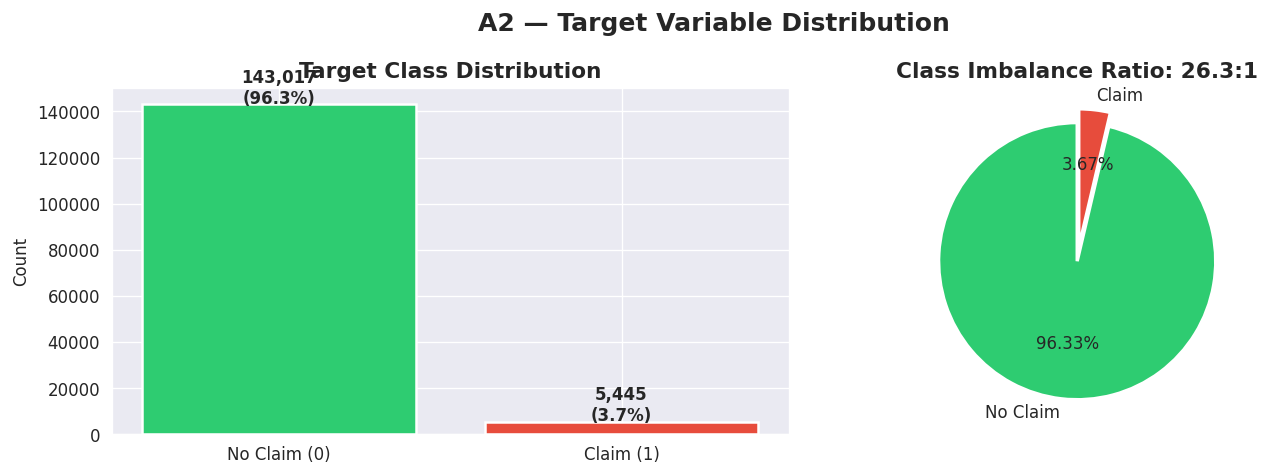

Dataset is HIGHLY IMBALANCED — ratio 26.3:1 (no-claim:claim)


In [11]:
# ── Target Distribution ───────────────────────────────────────────────
target_counts = train['target'].value_counts()
imbalance_ratio = target_counts[0] / target_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Claim (0)', 'Claim (1)'], target_counts.values,
            color=PALETTE, edgecolor='white', linewidth=1.5)
for i, (bar, val) in enumerate(zip(axes[0].patches, target_counts.values)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}\n({val/len(train)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=['No Claim', 'Claim'],
            autopct='%1.2f%%', colors=PALETTE,
            explode=[0, 0.1], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Class Imbalance Ratio: {imbalance_ratio:.1f}:1', fontsize=13, fontweight='bold')

plt.suptitle('A2 — Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('A2_target_distribution.png', bbox_inches='tight')
plt.show()
print(f'Dataset is HIGHLY IMBALANCED — ratio {imbalance_ratio:.1f}:1 (no-claim:claim)')

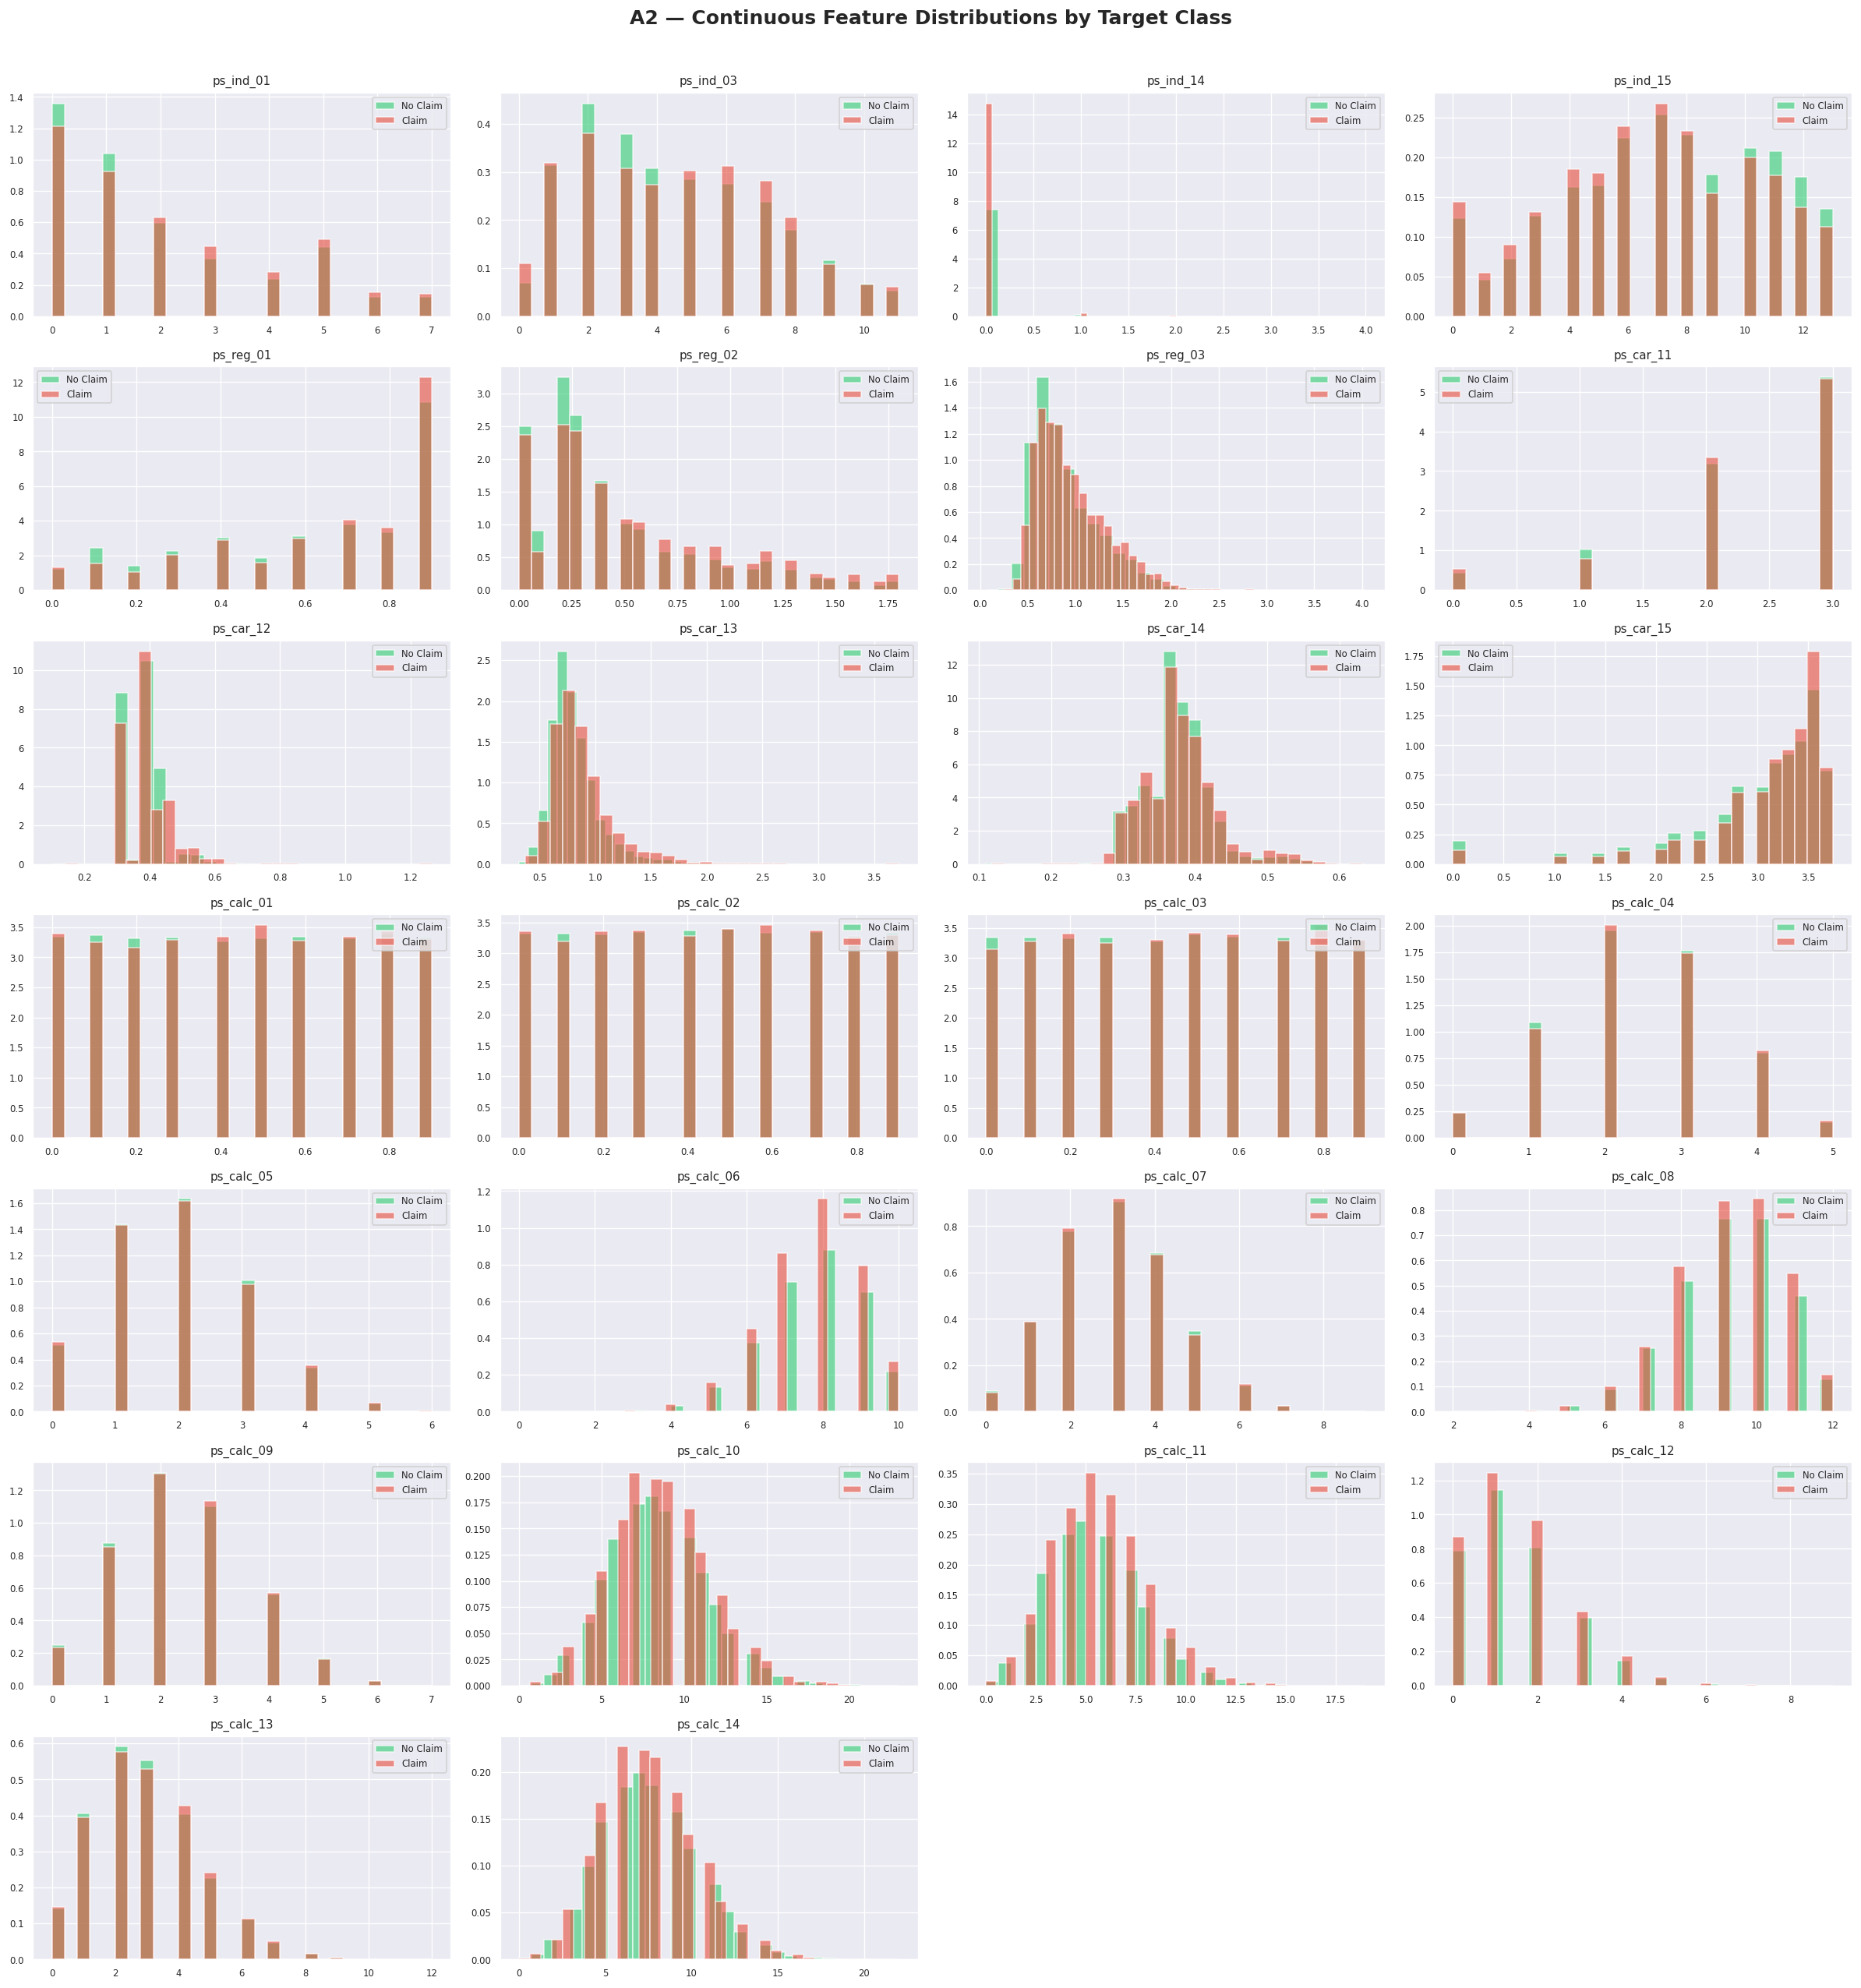

In [12]:
# ── Continuous Feature Distributions by Target ───────────────────────
# Replace -1 with NaN for plotting
train_plot = train.copy()
train_plot.replace(-1, np.nan, inplace=True)

n_cols = 4
n_rows = int(np.ceil(len(cont_feats) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(cont_feats):
    for t, color, label in zip([0, 1], PALETTE, ['No Claim', 'Claim']):
        data = train_plot[train_plot['target'] == t][feat].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('A2 — Continuous Feature Distributions by Target Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('A2_continuous_distributions.png', bbox_inches='tight')
plt.show()

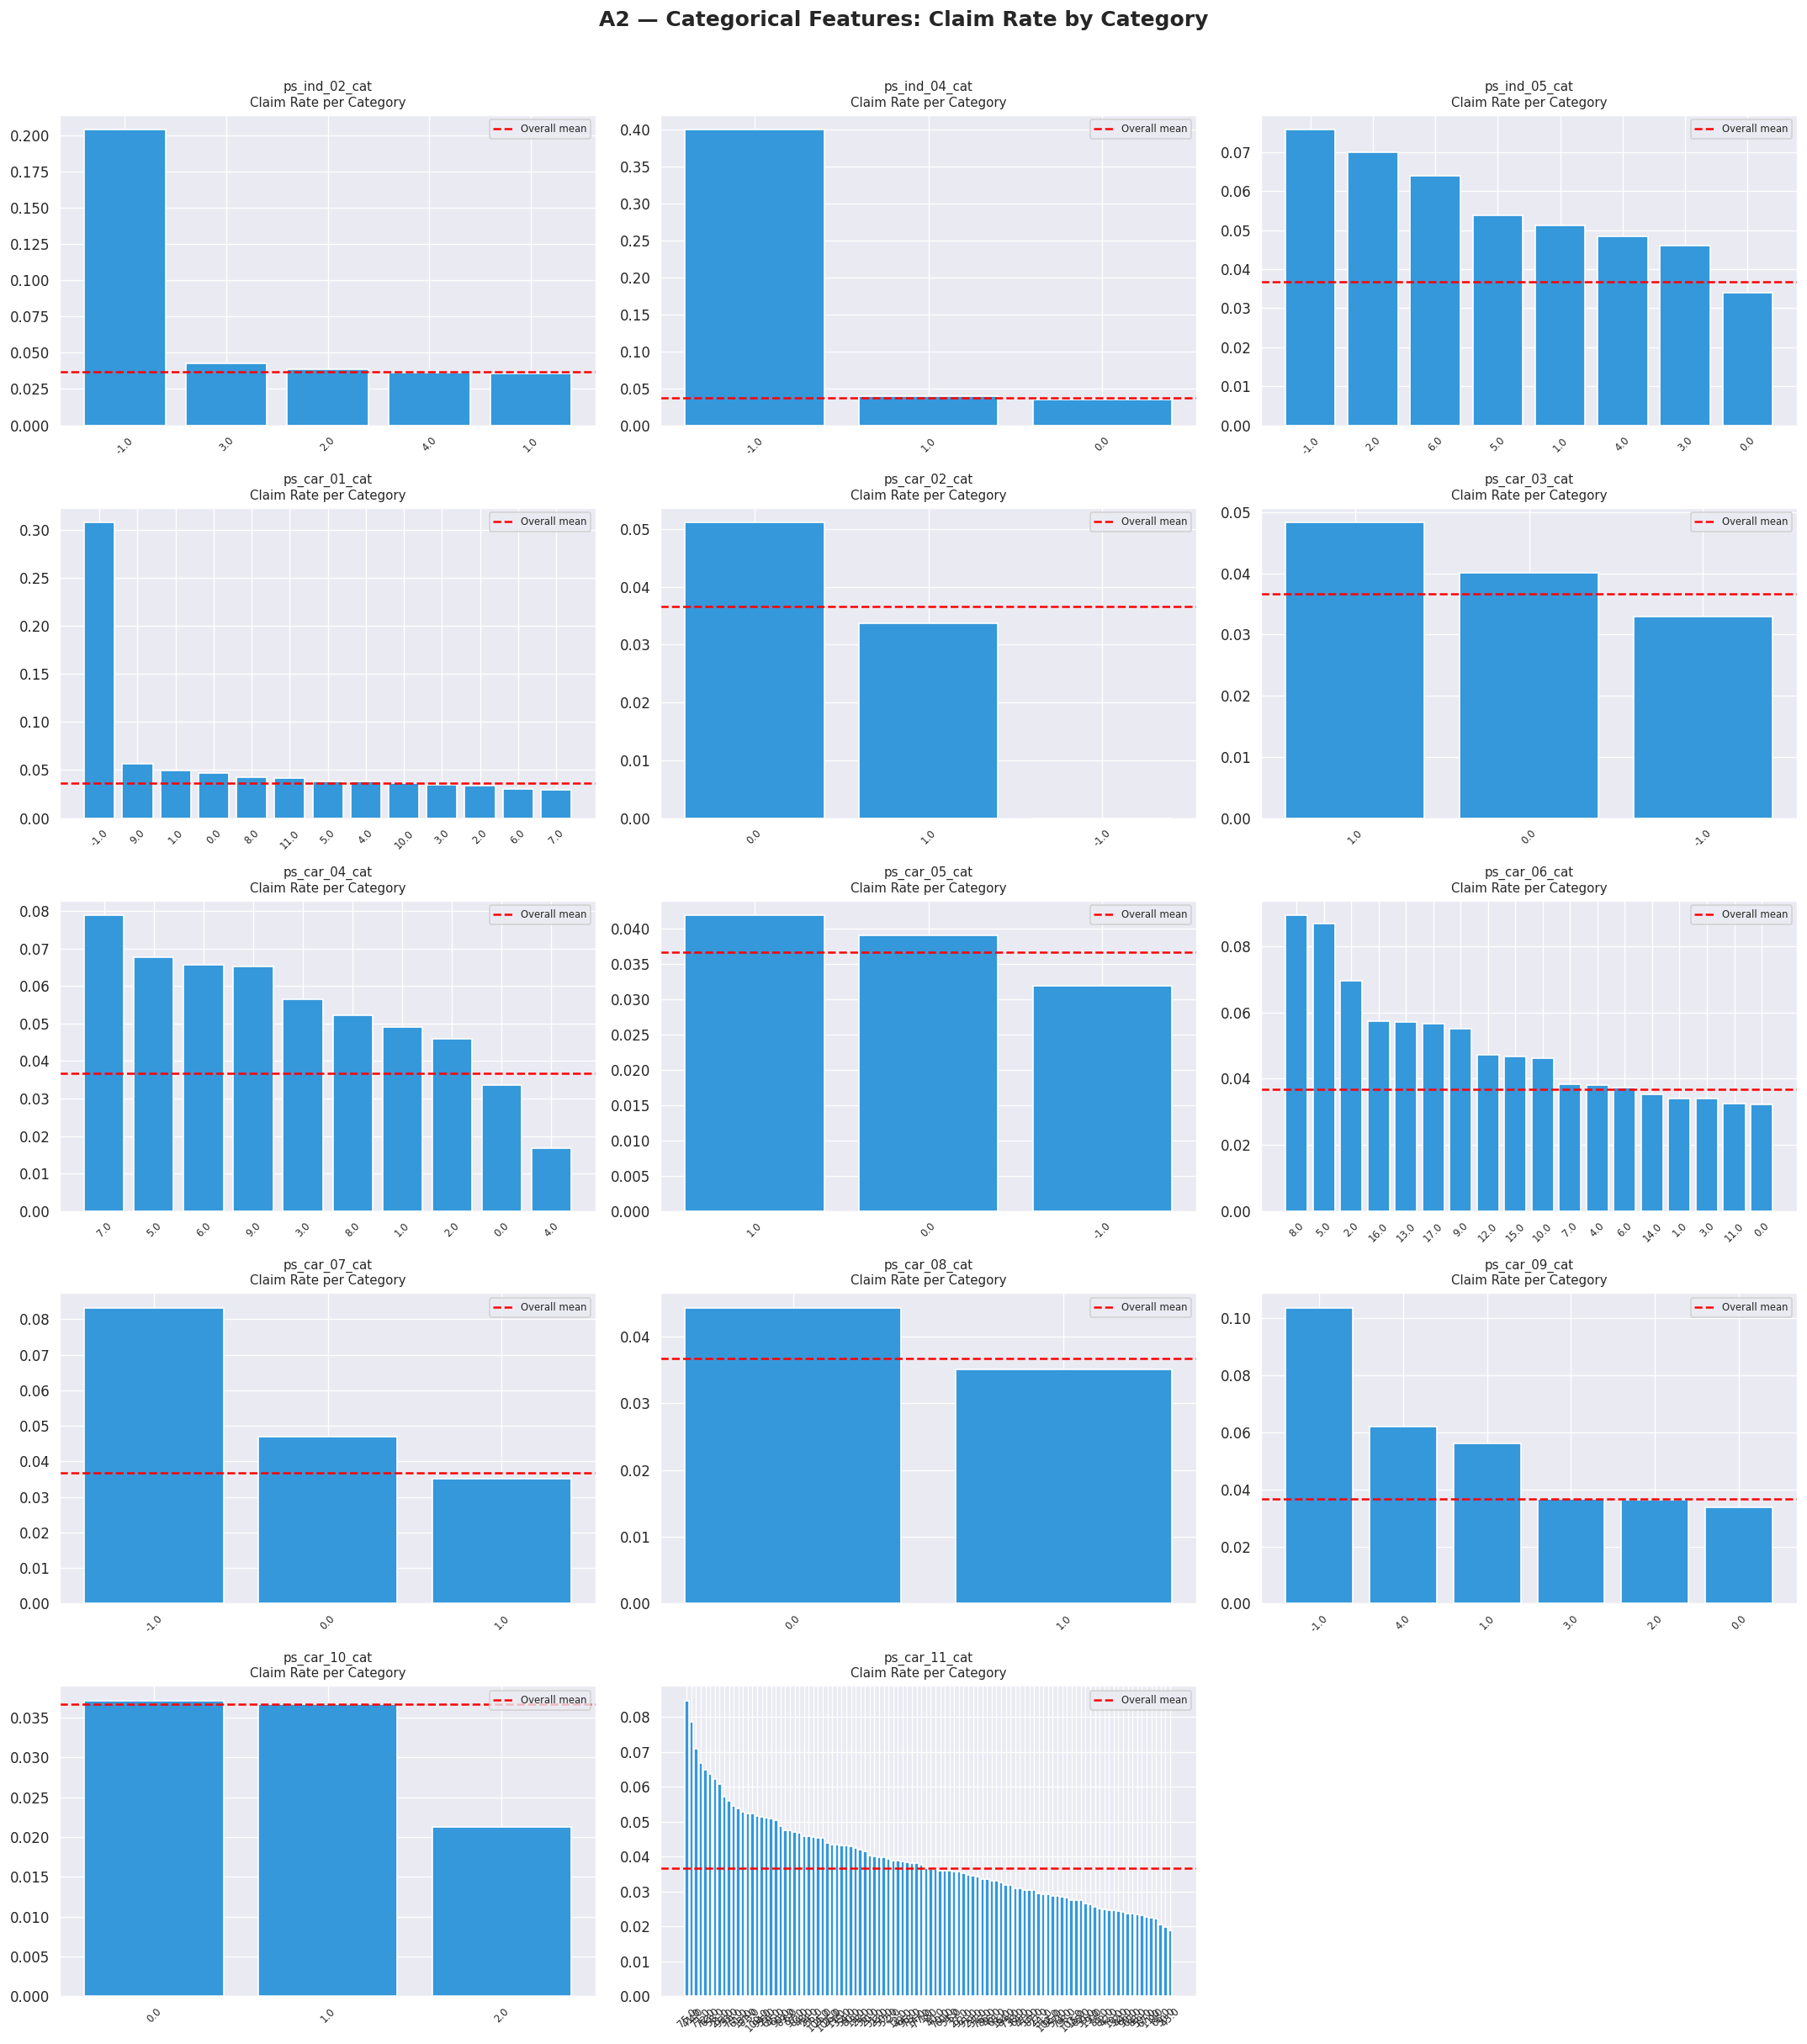

In [13]:
# ── Categorical Features — Claim Rate per Category ──────────────────
n_cols = 3
n_rows = int(np.ceil(len(cat_feats) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(cat_feats):
    claim_rate = train.groupby(feat)['target'].mean().sort_values(ascending=False)
    bars = axes[i].bar(claim_rate.index.astype(str), claim_rate.values,
                       color='#3498db', edgecolor='white')
    axes[i].axhline(train['target'].mean(), color='red', linestyle='--', linewidth=1.5, label='Overall mean')
    axes[i].set_title(f'{feat}\nClaim Rate per Category', fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('A2 — Categorical Features: Claim Rate by Category', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('A2_categorical_claim_rates.png', bbox_inches='tight')
plt.show()

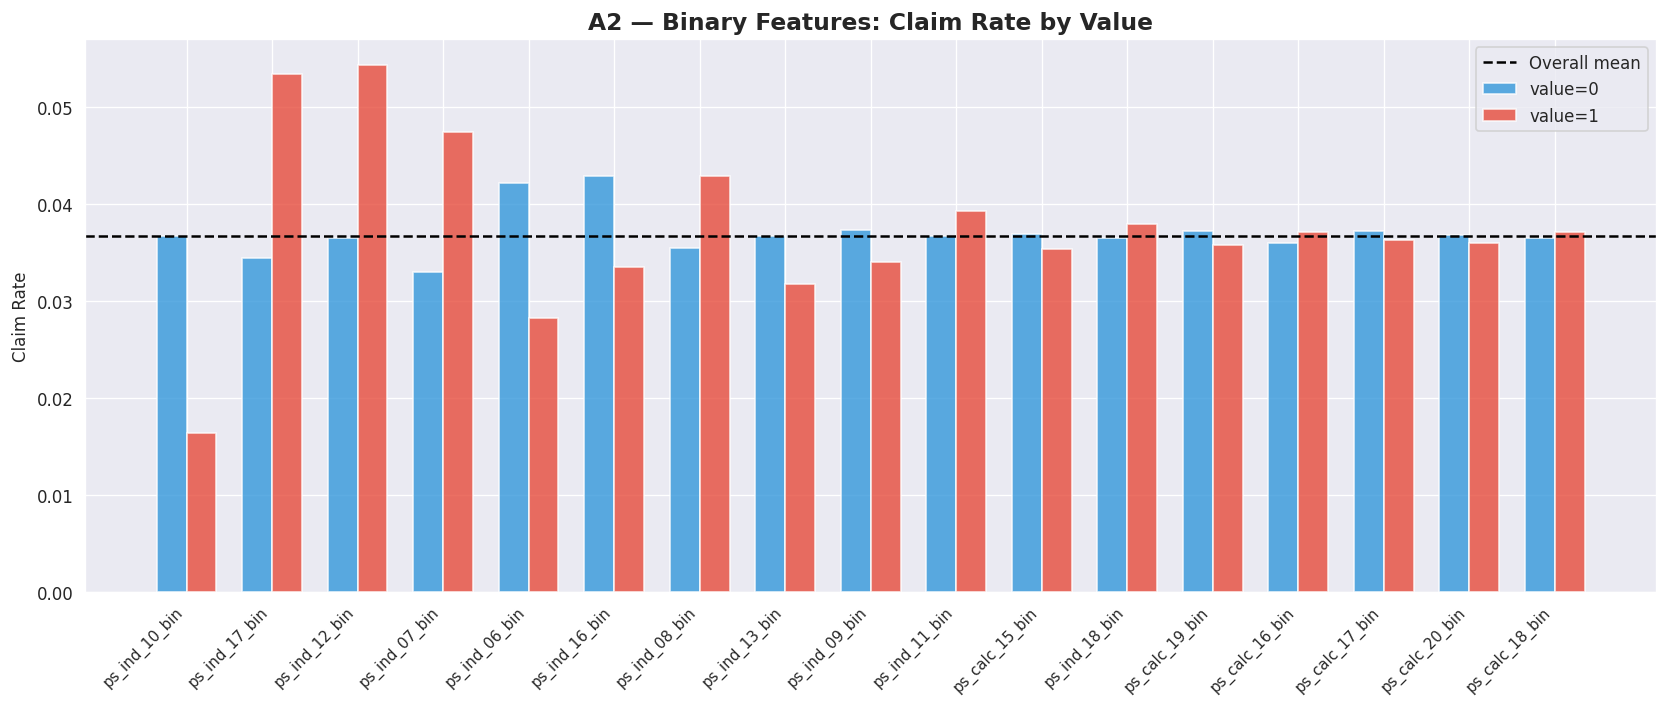

In [14]:
# ── Binary Features — Claim Rate ─────────────────────────────────────
bin_claim_rates = {}
for feat in bin_feats:
    rate_1 = train[train[feat]==1]['target'].mean()
    rate_0 = train[train[feat]==0]['target'].mean()
    bin_claim_rates[feat] = {'value=1': rate_1, 'value=0': rate_0}

bin_df = pd.DataFrame(bin_claim_rates).T
bin_df['diff'] = abs(bin_df['value=1'] - bin_df['value=0'])
bin_df = bin_df.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(bin_df))
width = 0.35
ax.bar(x - width/2, bin_df['value=0'], width, label='value=0', color='#3498db', alpha=0.8)
ax.bar(x + width/2, bin_df['value=1'], width, label='value=1', color='#e74c3c', alpha=0.8)
ax.axhline(train['target'].mean(), color='black', linestyle='--', label='Overall mean')
ax.set_xticks(x)
ax.set_xticklabels(bin_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Claim Rate')
ax.set_title('A2 — Binary Features: Claim Rate by Value', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('A2_binary_claim_rates.png', bbox_inches='tight')
plt.show()

## A3 — Missing Values and Feature Relationships

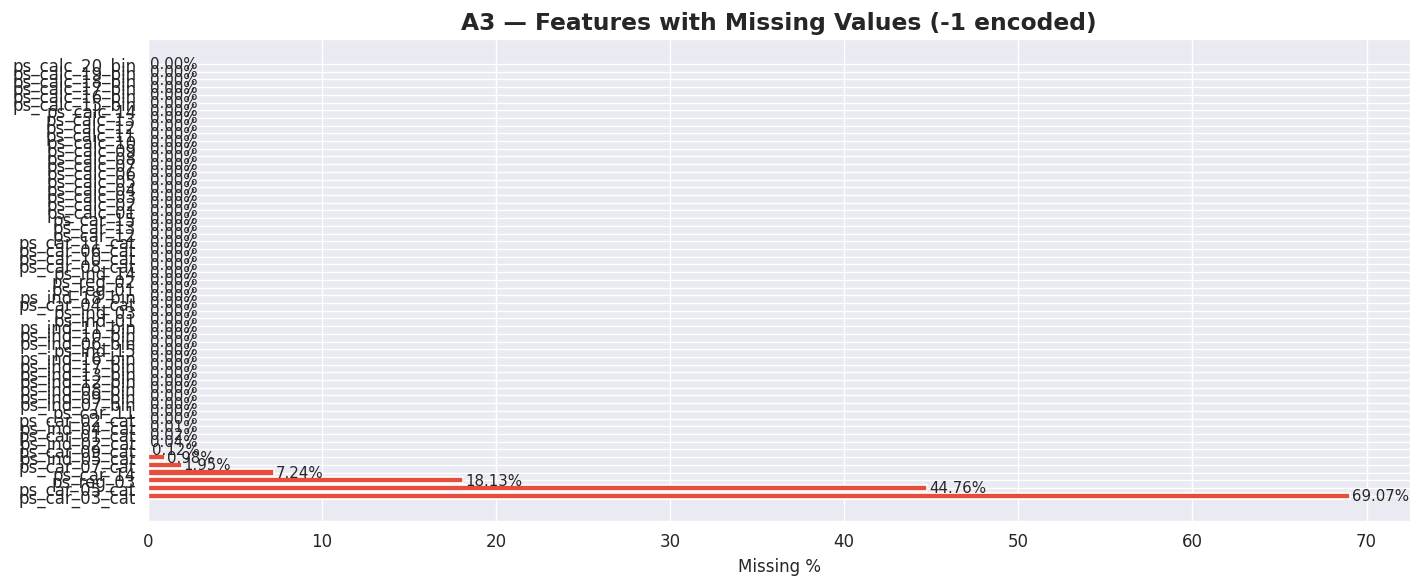

       feature  missing_count  missing_pct
 ps_car_03_cat         102543    69.069735
 ps_car_05_cat          66456    44.762668
     ps_reg_03          26913    18.127749
     ps_car_14          10745     7.237494
 ps_car_07_cat           2900     1.953349
 ps_ind_05_cat           1453     0.978695
 ps_car_09_cat            175     0.117874
 ps_ind_02_cat             55     0.037046
 ps_car_01_cat             27     0.018186
 ps_ind_04_cat             21     0.014145
 ps_car_02_cat              2     0.001347
     ps_car_11              2     0.001347
 ps_ind_07_bin              1     0.000674
 ps_ind_09_bin              1     0.000674
 ps_ind_08_bin              1     0.000674
 ps_ind_12_bin              1     0.000674
 ps_ind_13_bin              1     0.000674
 ps_ind_17_bin              1     0.000674
 ps_ind_16_bin              1     0.000674
     ps_ind_15              1     0.000674
 ps_ind_06_bin              1     0.000674
 ps_ind_10_bin              1     0.000674
 ps_ind_11_

In [15]:
# ── Missing Value Analysis ────────────────────────────────────────────
train_nan = train.replace(-1, np.nan)

missing_info = pd.DataFrame({
    'feature': features,
    'missing_count': [train_nan[f].isna().sum() for f in features],
    'missing_pct':   [train_nan[f].isna().mean()*100 for f in features]
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing_info['feature'], missing_info['missing_pct'],
               color='#e74c3c', edgecolor='white')
for bar, pct in zip(bars, missing_info['missing_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('A3 — Features with Missing Values (-1 encoded)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('A3_missing_values.png', bbox_inches='tight')
plt.show()
print(missing_info.to_string(index=False))

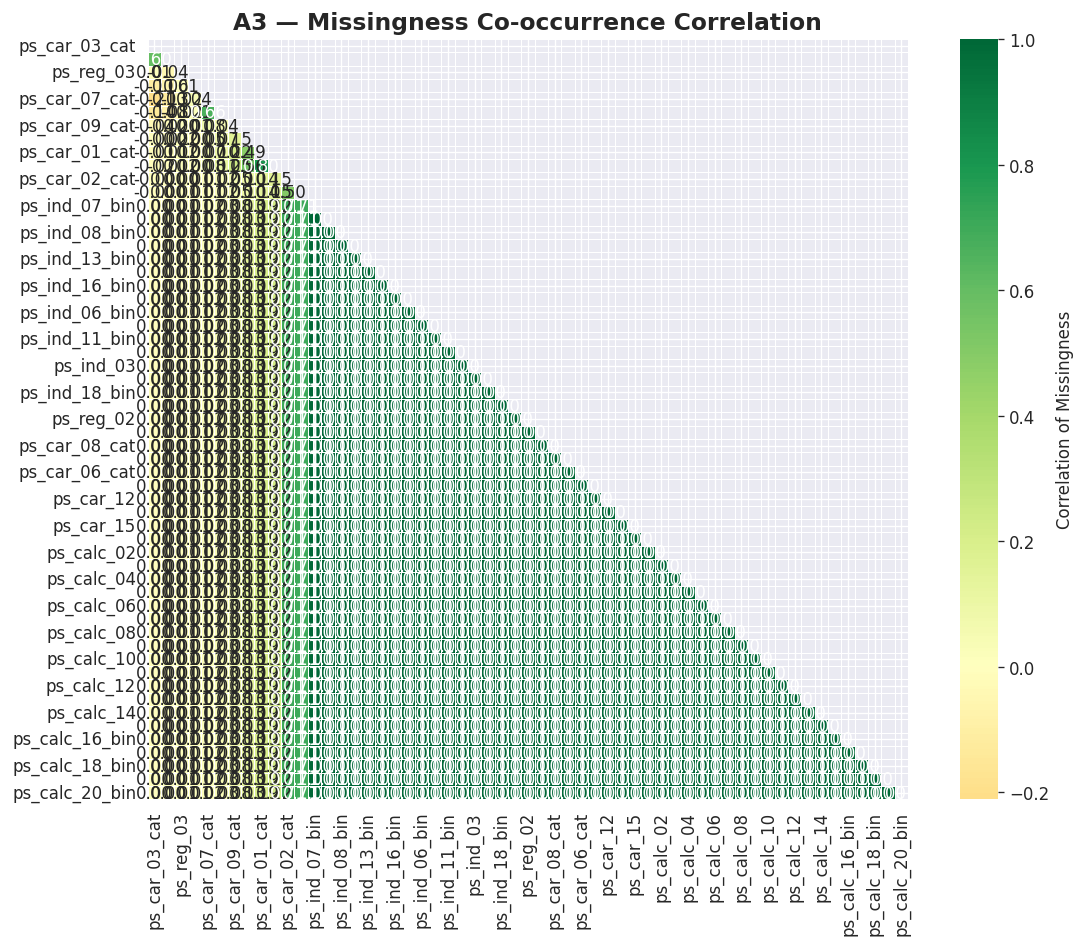

In [16]:
# ── Missing Value Co-occurrence Heatmap ──────────────────────────────
missing_feats = missing_info['feature'].tolist()
miss_indicators = (train_nan[missing_feats] == -1).astype(int)  # already NaN now
miss_indicators = train_nan[missing_feats].isna().astype(int)

miss_corr = miss_indicators.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(miss_corr, dtype=bool))
sns.heatmap(miss_corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation of Missingness'})
ax.set_title('A3 — Missingness Co-occurrence Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('A3_missing_cooccurrence.png', bbox_inches='tight')
plt.show()

In [17]:
# ── Claim Rate for Missing vs Non-Missing ────────────────────────────
# Does being missing carry predictive signal?
print('Claim Rate: Missing vs Non-Missing')
print(f'{"Feature":<25} {"Missing Rate":<15} {"Non-Missing Rate":<18} {"Diff"}')
print('-' * 65)

for feat in missing_feats:
    is_missing = train_nan[feat].isna()
    rate_missing    = train.loc[is_missing,    'target'].mean() if is_missing.sum() > 0 else np.nan
    rate_not_missing = train.loc[~is_missing,   'target'].mean()
    diff = rate_missing - rate_not_missing if not np.isnan(rate_missing) else np.nan
    print(f'{feat:<25} {str(round(rate_missing,4) if not np.isnan(rate_missing) else "N/A"):<15} {rate_not_missing:<18.4f} {str(round(diff,4)) if diff is not np.nan else "N/A"}')

Claim Rate: Missing vs Non-Missing
Feature                   Missing Rate    Non-Missing Rate   Diff
-----------------------------------------------------------------
ps_car_03_cat             0.0329          0.0451             -0.0122
ps_car_05_cat             0.0319          0.0405             -0.0086
ps_reg_03                 0.0286          0.0385             -0.0098
ps_car_14                 0.0425          0.0362             0.0063
ps_car_07_cat             0.0831          0.0358             0.0474
ps_ind_05_cat             0.0758          0.0363             0.0395
ps_car_09_cat             0.1034          0.0366             0.0669
ps_ind_02_cat             0.2037          0.0366             0.1671
ps_car_01_cat             0.3077          0.0366             0.2711
ps_ind_04_cat             0.4             0.0366             0.3634
ps_car_02_cat             0.0             0.0367             -0.0367
ps_car_11                 0.0             0.0367             -0.0367
ps_ind_07_bi

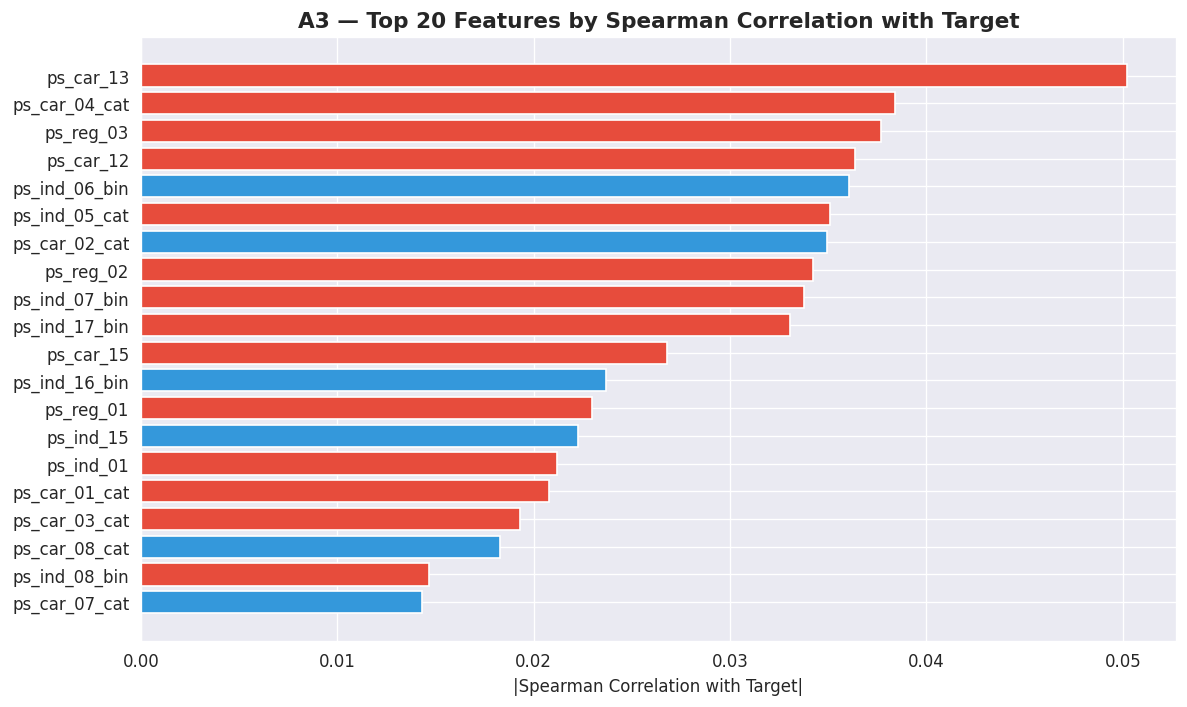

In [18]:
# ── Spearman Correlation Heatmap (top features with target) ─────────
from scipy.stats import spearmanr

train_corr = train.replace(-1, np.nan).copy()

# Compute Spearman correlation with target
spearman_corrs = {}
for feat in features:
    mask = train_corr[feat].notna()
    if mask.sum() > 100:
        r, _ = spearmanr(train_corr.loc[mask, feat], train.loc[mask, 'target'])
        spearman_corrs[feat] = r

corr_series = pd.Series(spearman_corrs).abs().sort_values(ascending=False)
top20 = corr_series.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if spearman_corrs[f] > 0 else '#3498db' for f in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('|Spearman Correlation with Target|')
ax.set_title('A3 — Top 20 Features by Spearman Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('A3_feature_target_correlation.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Imputation Strategy ───────────────────────────────────────────────
from sklearn.impute import SimpleImputer

train_imputed = train.replace(-1, np.nan).copy()
test_imputed  = test.replace(-1, np.nan).copy()

# Median imputation for continuous, mode for binary/categorical
for feat in features:
    if feat in bin_feats or feat in cat_feats:
        fill_val = train_imputed[feat].mode()[0]
    else:
        fill_val = train_imputed[feat].median()
    train_imputed[feat].fillna(fill_val, inplace=True)
    test_imputed[feat].fillna(fill_val, inplace=True)

print('Imputation complete ✓')
print(f'Remaining NaN in train: {train_imputed[features].isna().sum().sum()}')

# Save imputed datasets for use in Parts B and C
train_imputed.to_csv('/content/drive/MyDrive/cassandra/train_imputed.csv', index=False)
test_imputed.to_csv('/content/drive/MyDrive/cassandra/test_imputed.csv', index=False)
print('Saved imputed datasets to Drive ✓')

Imputation complete ✓
Remaining NaN in train: 0
Saved imputed datasets to Drive ✓


## Summary — Part A
| Finding | Detail |
|---------|--------|
| Total features | Printed above |
| Class imbalance | ~96% no-claim, ~4% claim |
| Missing values | Encoded as -1 in multiple features |
| Missingness signal | Some missing indicators correlate with claim rate |
| Top discriminative features | See Spearman correlation plot |
| Imputation strategy | Median (continuous), Mode (binary/categorical) |